In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import LinearRegression, Lasso, Ridge

# Линейная регрессия

In [148]:
class MyLinearRegression:
    def __init__(self):
        self.w = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        assert len(X.shape) == 2 and len(y.shape) == 1
        assert X.shape[0] == y.shape[0]

        l, n = X.shape
        y = y[:, np.newaxis]
        
        X_train = np.hstack((X, np.ones((l, 1))))
        self.w = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y

        return self

    def predict(self, X):
        l, n = X.shape

        X_train = np.hstack((X, np.ones((l, 1))))
        y_pred = X_train @ self.w

        return y_pred

    def get_weight(self):
        return self.w.copy()

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
def linear_expression(x):
    return 5 * x + 6

In [101]:
# по признакам сгенерируем значения таргетов с некоторым шумом
objects_num = 50
X = np.linspace(-5, 5, objects_num)
y = linear_expression(X) + np.random.randn(objects_num) * 5

# выделим половину объектов на тест
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5)

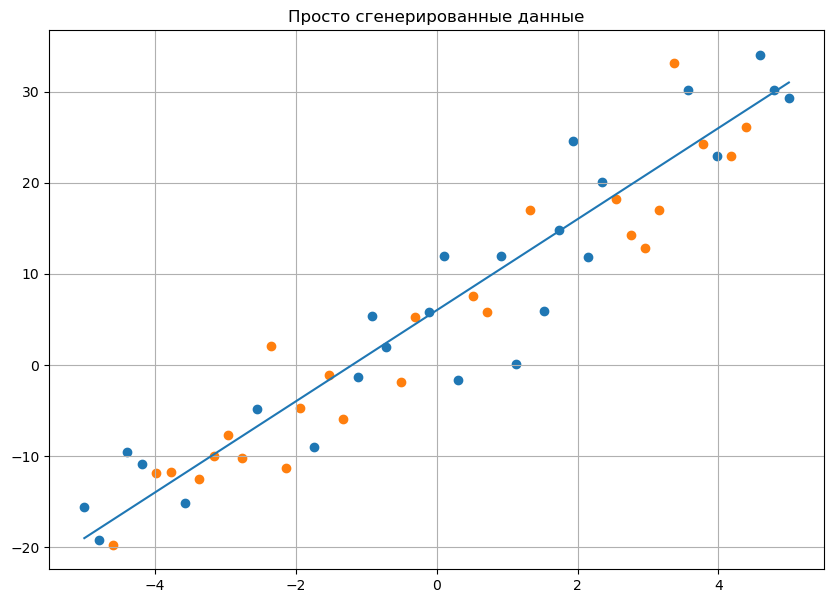

In [102]:
fig = plt.figure(figsize=(10,7))

plt.plot(X, linear_expression(X))
plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)

plt.title('Просто сгенерированные данные')

plt.grid()
plt.show()

In [103]:
X.shape

(50,)

In [104]:
regressor = MyLinearRegression()

regressor.fit(X_train[:, np.newaxis], y_train)

y_pred = regressor.predict(X_test[:, np.newaxis])
w = regressor.get_weight()
w

array([[4.88201122],
       [5.98287903]])

In [142]:
X_train[:, np.newaxis]

array([[-4.79591837],
       [-2.55102041],
       [-4.18367347],
       [ 0.30612245],
       [-0.10204082],
       [ 1.93877551],
       [ 4.59183673],
       [ 5.        ],
       [ 3.97959184],
       [ 2.14285714],
       [-0.71428571],
       [ 2.34693878],
       [ 4.79591837],
       [-1.12244898],
       [ 1.53061224],
       [ 1.73469388],
       [-5.        ],
       [-4.3877551 ],
       [ 1.12244898],
       [ 0.10204082],
       [-1.73469388],
       [-0.91836735],
       [ 0.91836735],
       [-3.57142857],
       [ 3.57142857]])

Теперь строим график вместе с линейной регрессией, берем ВСЮ ВЫБОРКУ

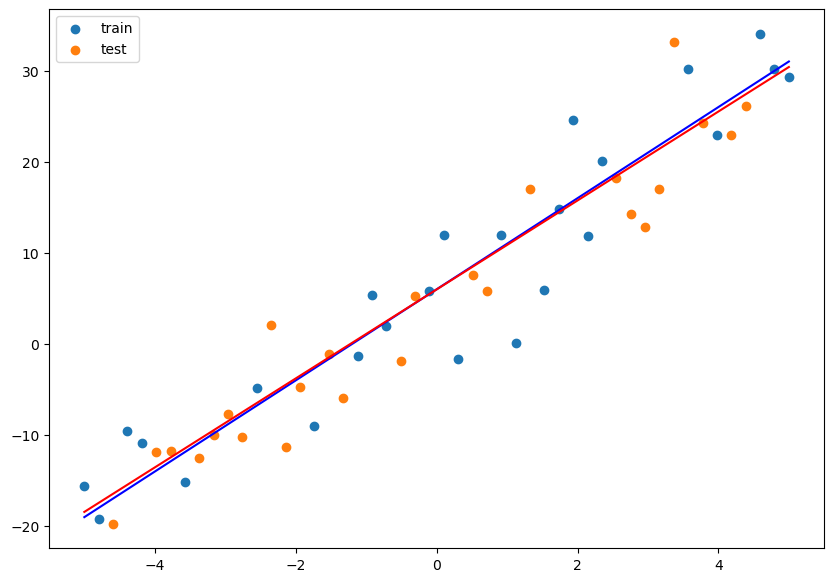

In [123]:
fig = plt.figure(figsize=(10,7))

plt.plot(X, linear_expression(X), color='blue')
plt.plot(X, regressor.predict(X[:, np.newaxis]), color='red')
plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')

plt.legend()
plt.show()

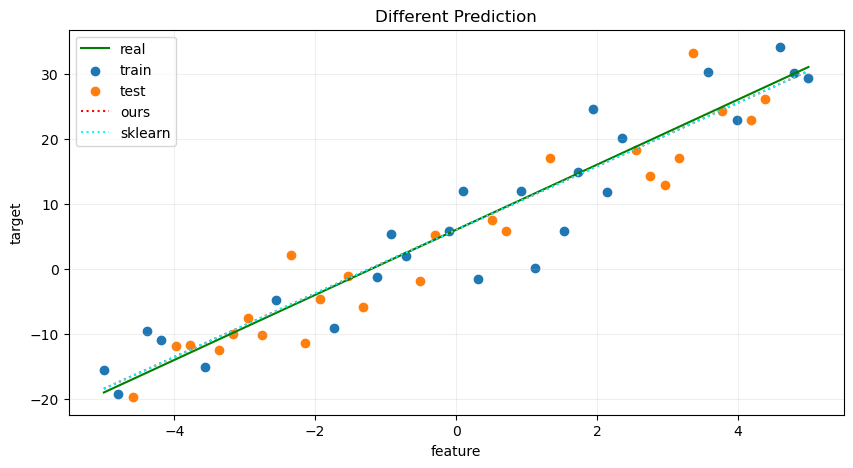

In [130]:
sk_reg = LinearRegression().fit(X_train[:, np.newaxis], y_train)

plt.figure(figsize=(10, 5))
plt.plot(X, linear_expression(X), label='real', c='g')

plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')
plt.plot(X, regressor.predict(X[:, np.newaxis]), label='ours', c='r', linestyle=':')
plt.plot(X, sk_reg.predict(X[:, np.newaxis]), label='sklearn', c='cyan', linestyle=':')

plt.title("Different Prediction")
plt.ylabel('target')
plt.xlabel('feature')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [144]:
from sklearn.metrics import mean_squared_error

train_predictions = regressor.predict(X_train[:, np.newaxis])
test_predictions = regressor.predict(X_test[:, np.newaxis])

print('Train MSE: ', mean_squared_error(y_train, train_predictions))
print('Test MSE: ', mean_squared_error(y_test, test_predictions))

Train MSE:  25.43182528674693
Test MSE:  18.403382679017213


# Градиентная оптимизация

In [158]:
class MyGradientLinearRegression(MyLinearRegression):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def fit(self, X, y, lr=0.01, max_iter=100):
        X = np.array(X)
        y = np.array(y)

        assert len(X.shape) == 2 and len(y.shape) == 1
        assert X.shape[0] == y.shape[0]

        l, n = X.shape
        y = y[:, np.newaxis]

        X_train = np.hstack((X, np.ones((l, 1))))

        self.w = np.random.rand(n + 1,1)
        self.losses = []

        for iter_num in range(max_iter):
            y_pred = self.predict(X) #X_train
            self.losses.append(mean_squared_error(y, y_pred))

            grad = self.calc_gradient(X, y, y_pred)

            self.w -= lr * grad

        return self
            
    def calc_gradient(self, X, y, y_pred):
        grad = (2. / X.shape[0]) * (X.T @ (y_pred - y))
        return grad

    def get_losses(self):
        return self.losses

In [166]:
regressor = MyGradientLinearRegression()
loss = regressor.fit(X_train[:, np.newaxis], y_train, max_iter=100).get_losses()

predictions = regressor.predict(X_test[:, np.newaxis])
w = regressor.get_weight()
w

array([[4.89532831],
       [5.37362616]])

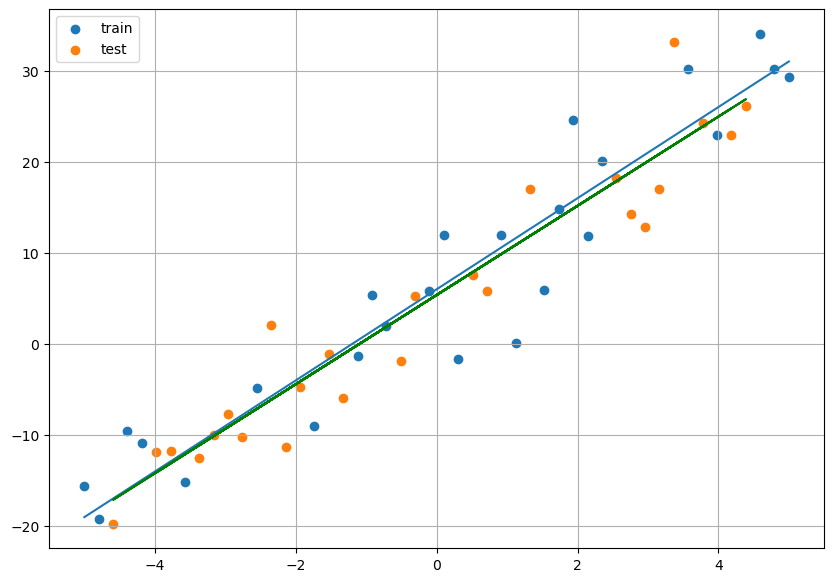

In [176]:
fig = plt.figure(figsize=(10,7))

plt.plot(X, linear_expression(X))
plt.plot(X_test, predictions, color='green')

plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')

plt.legend()
plt.grid()
plt.show()

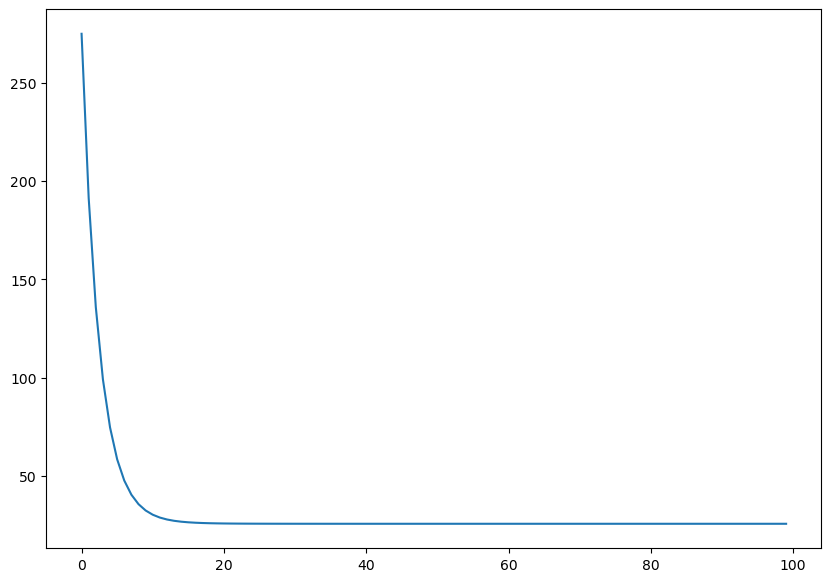

In [180]:
fig = plt.figure(figsize=(10,7))

plt.plot(loss)
plt.show()

# Стохастический Градиентный спуск (SGD)

In [187]:
class MySGDLinearRegression(MyGradientLinearRegression):
    def __init__(self, n_sample=10, **kwargs):
        super().__init__(**kwargs)
        self.n_sample = n_sample

    def calc_gradient(self, X, y, y_pred):
        indexes = np.random.choice(np.arange(X.shape[0]), size=self.n_sample, replace=False)

        grad = 2 / self.n_sample * X[indexes].T @ (y_pred[indexes] - y[indexes])
        return grad

In [193]:
regressor = MySGDLinearRegression()

l = regressor.fit(X_train[:, np.newaxis], y_train, max_iter=100).get_losses()

predictions = regressor.predict(X_test[:, np.newaxis])
w = regressor.get_weight()
w

array([[4.83577666],
       [4.93113346]])

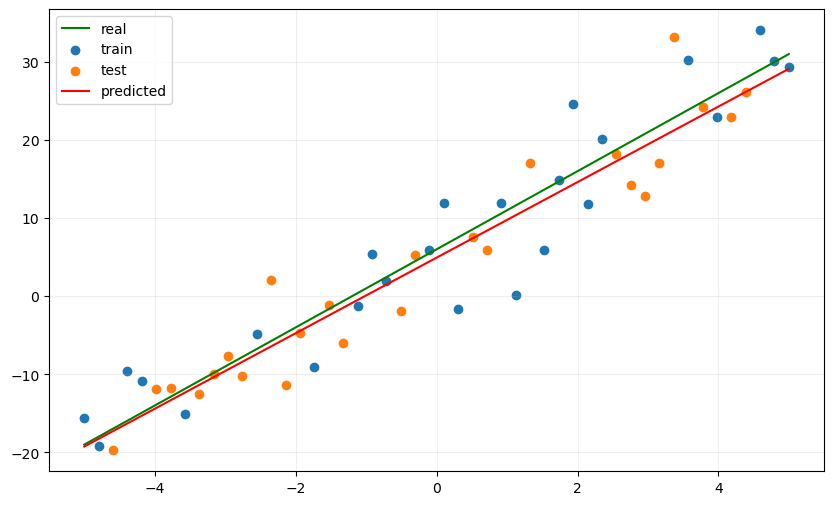

In [195]:
plt.figure(figsize=(10, 6))
plt.plot(X, linear_expression(X), label='real', c='g')

plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')
plt.plot(X, regressor.predict(X[:, np.newaxis]), label='predicted', c='r')

plt.grid(alpha=0.2)
plt.legend()
plt.show()

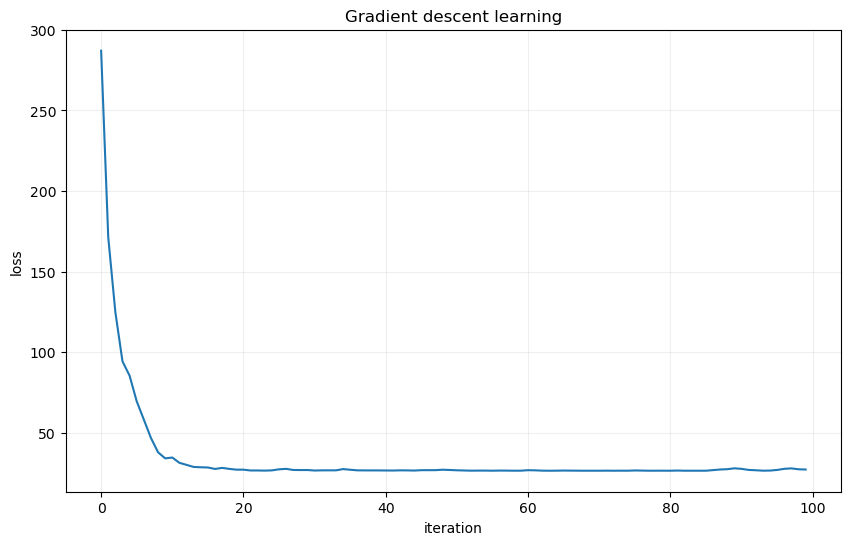

In [197]:
plt.figure(figsize=(10, 6))

plt.plot(l)

plt.title('Gradient descent learning')
plt.ylabel('loss')
plt.xlabel('iteration')
plt.grid(alpha=0.2)
plt.show()

In [199]:
n_samples = [1, 4, 16]

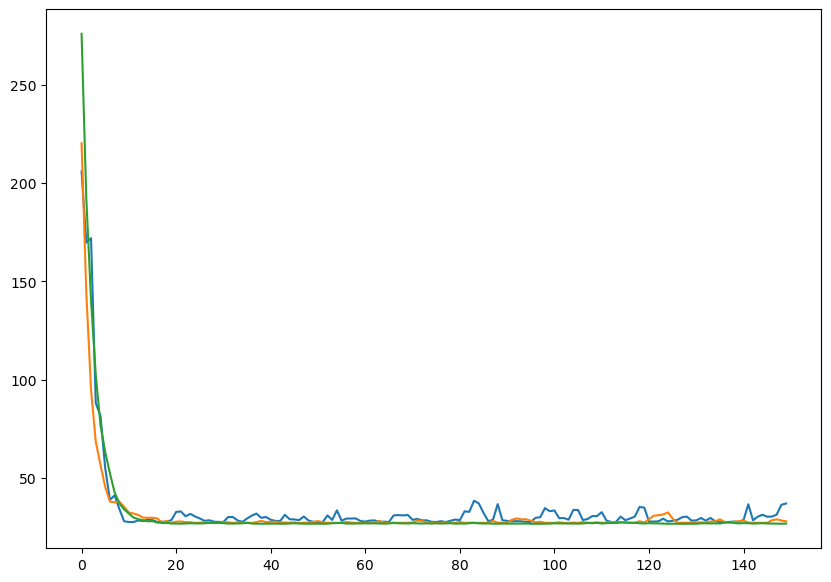

In [203]:
fig = plt.figure(figsize=(10,7))

for n in n_samples:
    regressor = MySGDLinearRegression(n_sample=n)
    l = regressor.fit(X_train[:, np.newaxis], y_train, max_iter=150).get_losses()
    plt.plot(l)

plt.show()